# 43 — PEP α ↔ our-dose mapping (no GPU, re-analysis only)

**Purpose.** Line up PEP's steering-strength knob `α` with this project's `dose`
axis, so the claim *"2× breaks folding"* can be checked against PEP's *"α ≈ 1–2 is safe."*
Both `α` and `dose` are **multipliers on a steering vector's natural norm**, so the
map between them is a **pure ratio of vector norms** — it needs no GPU, no re-run,
and (crucially) does *not* depend on the residual-stream norm ‖h‖.

Every input is a file-locked scalar from a saved run (sources cited inline). This
notebook only does arithmetic + one figure. Run it top-to-bottom and commit the outputs.

PEP = *Controlling Repetition in Protein Language Models* (Zhang et al., arXiv:2602.00782, ICLR 2026).

## The mapping, in one line

PEP injects `h + α·v_PEP`; we inject `h + dose·v_naive`. Our naive vector's natural
norm is exactly the project REFERENCE_NORM (583.998), so **our dose axis = multiples
of 583.998**. Matching the *injected magnitude*:

```
dose = α · ‖v_PEP‖ / 583.998
```

We don't have PEP's vector, but its recipe (utility-matched contrastive
mean-difference) is exactly our **utility-matched** vector, whose natural norm we
measured as **328.8–439.6** across two independent builds. We carry that as a band,
so each PEP `α` maps to a *range* of our doses. Collapse is then read off the NB37
dose-response logistic fit. The whole argument is about magnitude, so ‖h‖ cancels.

In [1]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# FILE-LOCKED INPUTS  (transcribed from saved notebook outputs / notes/locked-results.md)
# Every number below is a measured scalar from a prior run. Re-verify against the
# cited source before trusting a downstream number. NO GPU / NO re-run needed here.
# =============================================================================

# --- Our steering vectors' NATURAL norms (ProtGPT2, layer 12) ----------------
# NAIVE repetition vector used to build the dose-response curve (NB37 / NB35).
# Its natural norm already equals REFERENCE_NORM, so our dose axis is literally
# 'multiples of this vector's own natural norm'.
NAIVE_VEC_NORM = 583.998        # = REFERENCE_NORM. Source: NB37/NB35 output; locked-results 1a.

# UTILITY-MATCHED vector (NB24 recipe) = PEP's true methodological analogue
# (contrastive D+/D- matched on utility, separated on repetition). Natural norm
# measured in two independent builds; carry BOTH as a band.
MATCHED_VEC_NORM_LOW  = 328.844  # Source: NB36 output ('repetition vector, 24 recipe').
MATCHED_VEC_NORM_HIGH = 439.619  # Source: NB34/NB25 norm audit; locked-results 1k (439.6188).

# --- Dose-response logistic fit (NB37 / locked-results 1n) -------------------
# p(dose) = FLOOR + (1 - FLOOR) * sigmoid( K * (dose - DOSE50) )
# Floor pinned at observed CONTROL collapse rate. Fit over 0.0x..2.0x ladder, N=50/dose.
FIT_FLOOR     = 0.640            # observed CONTROL collapse rate (dose-response run)
FIT_K         = 9.48             # slope
FIT_DOSE50    = 1.240            # dose at half-rise; = alpha_rel 0.2131
FIT_DOSE50_CI = (1.14, 1.32)     # bootstrap 95% CI on dose50
SAFE_BUDGET_DOSE = 1.25          # largest dose with no significant collapse (Fisher p=0.0705)

# Empirical dose-response ladder (dose -> collapse fraction), NB37, N=50/dose.
DOSE_LADDER = [
    (0.00, 0.64), (0.50, 0.50), (0.75, 0.50), (1.00, 0.66),
    (1.25, 0.82), (1.50, 1.00), (1.75, 0.98), (2.00, 1.00),
]

# Fair-test points on the UTILITY-MATCHED direction, rescaled to REFERENCE_NORM,
# so they live on the SAME injected-magnitude axis as the dose ladder (NOT on PEP's
# alpha axis). Cross-check that direction barely matters vs magnitude. Source: 1g.
FAIR_TEST = [(0.00, 0.62), (1.00, 0.60), (2.00, 0.90)]

# --- PEP's operating points (arXiv:2602.00782) -------------------------------
# All PEP headline 'preserves foldability' results are at alpha=1. PEP's own
# ablation (5.3) says utility declines past alpha ~ 2 ('sweet spot' a=1, 'Stable' a=2).
PEP_ALPHAS = [1.0, 2.0]

# --- Residual-stream norm (ONLY for the optional alpha_rel column) -----------
# NOTE: ||h|| varies run-to-run; the PEP->dose map is a PURE NORM RATIO and does
# NOT use ||h||. Source: NB37 ||h||=3397.13 (dose run); NB34 ||h||=2921.53.
H_NORM_DOSE_RUN = 3397.13

print('inputs loaded; naive norm =', NAIVE_VEC_NORM,
      '| matched band =', MATCHED_VEC_NORM_LOW, '-', MATCHED_VEC_NORM_HIGH)

inputs loaded; naive norm = 583.998 | matched band = 328.844 - 439.619


In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

def collapse_at_dose(dose):
    'Collapse fraction predicted by the NB37 floored-logistic fit.'
    return FIT_FLOOR + (1.0 - FIT_FLOOR) * sigmoid(FIT_K * (dose - FIT_DOSE50))

# Core map: PEP injects alpha*||v_PEP|| ; we inject dose*||v_naive||.
# Equal injected magnitude => dose = alpha * ||v_PEP|| / ||v_naive||.
# ||v_PEP|| unknown; our utility-matched vector is its analogue, carried as a band.
def pep_alpha_to_dose(alpha, matched_norm):
    return alpha * matched_norm / NAIVE_VEC_NORM

rows = []
for alpha in PEP_ALPHAS:
    dose_low  = pep_alpha_to_dose(alpha, MATCHED_VEC_NORM_LOW)   # smaller norm -> smaller dose
    dose_high = pep_alpha_to_dose(alpha, MATCHED_VEC_NORM_HIGH)
    rows.append({
        'pep_alpha':      alpha,
        'our_dose_low':   dose_low,
        'our_dose_high':  dose_high,
        'collapse_low':   collapse_at_dose(dose_low),
        'collapse_high':  collapse_at_dose(dose_high),
        'alpha_rel_low':  dose_low  * NAIVE_VEC_NORM / H_NORM_DOSE_RUN,
        'alpha_rel_high': dose_high * NAIVE_VEC_NORM / H_NORM_DOSE_RUN,
    })

rows

[{'pep_alpha': 1.0,
  'our_dose_low': 0.5630909694896215,
  'our_dose_high': 0.752774838269994,
  'collapse_low': 0.6405870615347948,
  'collapse_high': 0.6435162466669314,
  'alpha_rel_low': 0.09680053456888608,
  'alpha_rel_high': 0.12940894225419694},
 {'pep_alpha': 2.0,
  'our_dose_low': 1.126181938979243,
  'our_dose_high': 1.505549676539988,
  'collapse_low': 0.731330635357686,
  'collapse_high': 0.9731272287760158,
  'alpha_rel_low': 0.19360106913777217,
  'alpha_rel_high': 0.2588178845083939}]

In [3]:
print('PEP alpha -> our dose (band)   |  predicted collapse (band)  |  alpha_rel (band)')
print('-' * 78)
for r in rows:
    a      = r['pep_alpha']
    dlo    = r['our_dose_low'];  dhi = r['our_dose_high']
    clo    = 100 * r['collapse_low'];  chi = 100 * r['collapse_high']
    alo    = r['alpha_rel_low'];  ahi = r['alpha_rel_high']
    dose_s = f'{dlo:.3f}-{dhi:.3f}x'
    col_s  = f'{clo:.0f}%-{chi:.0f}%'
    ar_s   = f'{alo:.3f}-{ahi:.3f}'
    print(f'   alpha={a:.0f}   ->   {dose_s:>16}   |   {col_s:>16}   |   {ar_s:>14}')

print()
print(f'collapse cliff (dose-response): dose50 = {FIT_DOSE50}x '
      f'(CI {FIT_DOSE50_CI[0]}-{FIT_DOSE50_CI[1]}); safe budget <= {SAFE_BUDGET_DOSE}x')
print(f'CONTROL / baseline collapse (no steering): {100*FIT_FLOOR:.0f}%')

PEP alpha -> our dose (band)   |  predicted collapse (band)  |  alpha_rel (band)
------------------------------------------------------------------------------
   alpha=1   ->       0.563-0.753x   |            64%-64%   |      0.097-0.129
   alpha=2   ->       1.126-1.506x   |            73%-97%   |      0.194-0.259

collapse cliff (dose-response): dose50 = 1.24x (CI 1.14-1.32); safe budget <= 1.25x
CONTROL / baseline collapse (no steering): 64%


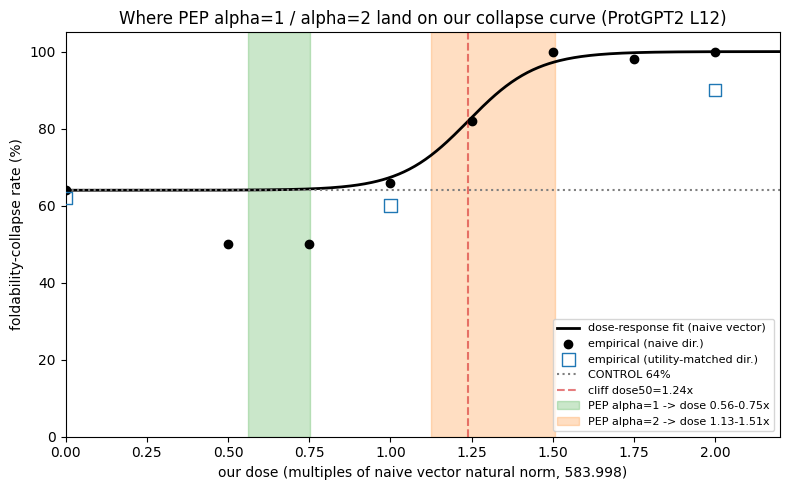

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# fitted dose-response curve
xs = np.linspace(0, 2.2, 400)
ys = [100 * collapse_at_dose(x) for x in xs]
ax.plot(xs, ys, color='black', lw=2, label='dose-response fit (naive vector)')

# empirical dose-response points (naive direction)
ax.scatter([d for d, _ in DOSE_LADDER], [100*c for _, c in DOSE_LADDER],
           color='black', zorder=5, label='empirical (naive dir.)')

# fair-test points (utility-matched direction, same magnitude axis)
ax.scatter([d for d, _ in FAIR_TEST], [100*c for _, c in FAIR_TEST],
           marker='s', facecolors='none', edgecolors='tab:blue', s=80, zorder=5,
           label='empirical (utility-matched dir.)')

# CONTROL baseline + cliff
ax.axhline(100*FIT_FLOOR, ls=':', color='gray', label=f'CONTROL {100*FIT_FLOOR:.0f}%')
ax.axvline(FIT_DOSE50, ls='--', color='tab:red', alpha=0.6,
           label=f'cliff dose50={FIT_DOSE50}x')

# PEP alpha bands mapped onto our dose axis
band_colors = {1.0: 'tab:green', 2.0: 'tab:orange'}
for r in rows:
    a = r['pep_alpha']
    ax.axvspan(r['our_dose_low'], r['our_dose_high'],
               color=band_colors.get(a, 'gray'), alpha=0.25,
               label=f'PEP alpha={a:.0f} -> dose {r["our_dose_low"]:.2f}-{r["our_dose_high"]:.2f}x')

ax.set_xlabel('our dose (multiples of naive vector natural norm, 583.998)')
ax.set_ylabel('foldability-collapse rate (%)')
ax.set_title('Where PEP alpha=1 / alpha=2 land on our collapse curve (ProtGPT2 L12)')
ax.set_ylim(0, 105)
ax.set_xlim(0, 2.2)
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()
plt.show()

In [5]:
OUT_PNG = 'pep_alpha_mapping.png'
OUT_PDF = 'pep_alpha_mapping.pdf'
OUT_CSV = 'pep_alpha_mapping.csv'

fig.savefig(OUT_PNG, dpi=200, bbox_inches='tight')
fig.savefig(OUT_PDF, bbox_inches='tight')

with open(OUT_CSV, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    for r in rows:
        w.writerow(r)

print('wrote:', OUT_PNG, OUT_PDF, OUT_CSV)
print('(move these into analysis/ next to the other CSVs when committing)')

wrote: pep_alpha_mapping.png pep_alpha_mapping.pdf pep_alpha_mapping.csv
(move these into analysis/ next to the other CSVs when committing)


## Reading the result (Framing B — independent cross-check)

- **PEP α=1 → our dose ≈ 0.56–0.75×.** That sits *below* our collapse cliff
  (dose50 = 1.24×). Predicted collapse ≈ the CONTROL baseline (~64%): at PEP's
  headline dose our raw-pLDDT readout shows **no significant *added* collapse** —
  consistent with PEP's "preserves foldability" claim.
- **PEP α=2 (their own upper "Stable" bound) → our dose ≈ 1.13–1.51×.** That
  *straddles / crosses* the cliff. Predicted collapse ≈ 73–97%.

So the safe window is **real but narrow**: it survives our stricter structural
readout at α=1, but its upper edge — which PEP still labels "Stable" — coincides
with catastrophic collapse under raw ESMFold pLDDT. We are **not** overturning PEP;
we are measuring how thin the safe band is with an independent ruler.

**Metric gap, to state alongside every number:** PEP's utility U is a normalized
AlphaFold (pLDDT+pTM) composite on a 0–1 scale and *rises* 0.621→0.711; ours is a
raw ESMFold pLDDT<60 collapse rate that stays flat at ~64% at α=1. Same qualitative
story at α=1 (no degradation), different instrument.

### Three assumptions this mapping rests on (do not drop these)
1. **‖v_PEP‖ ≈ our utility-matched norm.** PEP never reports its vector's norm; we
   proxy it with our own recipe's 328.8–439.6 band. If PEP's vector is *larger*, its
   α maps to a *higher* dose (worse for PEP); if smaller, lower. The band brackets this.
2. **Collapse-vs-magnitude is ~direction-agnostic.** Supported here by the
   utility-matched fair-test points landing on the naive dose-response curve (§1g
   overlay), and by the random-direction control (§1l).
3. **Predictor + layer mismatch.** PEP's exact injection layer is unstated and PEP
   uses AlphaFold; we use ESMFold at L12. The map is a *magnitude* argument, not a
   claim that the two pipelines are identical.

### When you run this — sanity checks
- Confirm `MATCHED_VEC_NORM_{LOW,HIGH}` against NB36 / NB34 cell outputs.
- Confirm the fit params (FLOOR 0.640, K 9.48, DOSE50 1.240) against NB37 / §1n.
- The α=1 band should print ~64% collapse and the α=2 band ~73–97%. If not, a
  norm or fit constant was mistyped.